# Feature extraction — all datasets

Loads the burst embedding + waveform data for each dataset (Mossink, Hommersom, Wagenaar, BIC), computes the same derived burst-shape features used in `Fig3.ipynb` (`fwhm`, bimodality coefficient `bc`, `tau_rise`, `tau_decay`), and saves one dataframe per dataset plus a combined dataframe so all four can be analyzed together.

In [ ]:
import os

import numpy as np
import pandas as pd

na = np.array
from burst_shape.folders import get_fig_folder

out_dir = os.path.join(get_fig_folder(), "combined_features") + "/"
os.makedirs(out_dir, exist_ok=True)
import os
import sys

from burst_shape.folders import get_fig_folder, get_project_folder

sys.path.insert(0, os.path.join(get_project_folder(), "scripts", "6_other"))
from Fig_supp_helpers import (
    load_dataset,
    load_df_cultures,
    savefig,
    spearman_ignore_nan,
)

%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

na = np.array
import matplotlib.colors as mcolors
import seaborn as sns

cmap = sns.color_palette("viridis", as_cmap=True)
norm = mcolors.Normalize(vmin=1, vmax=50)
# Create a dummy ScalarMappable for the colorbar

cmap = sns.color_palette("viridis", as_cmap=True)
norm = mcolors.Normalize(vmin=1, vmax=50)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

## Mossink

In [261]:
burst_params = (
    "burst_dataset_mossink_maxISIstart_100_maxISIb_50_minBdur_10"
    "0_minIBI_500_n_bins_50_normalization_integral_min_length_30"
)
df_mossink = load_dataset(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_85"
)
df_mossink["dataset"] = "mossink"
# df_mossink.to_pickle(out_dir + 'df_mossink.pkl')
df_mossink_orig = load_df_cultures(burst_params)
df_mossink_orig = df_mossink_orig.reset_index()
df_mossink_orig["dataset"] = "Kleesfstra"
# df_mossink.to_pickle(out_dir + 'df_orig_mossink.pkl')

## Hommersom

In [ ]:
burst_params = (
    "burst_dataset_hommersom_binary_maxISIstart_20_maxISIb_20_minBdur_50_m"
    "inIBI_100_minSburst_100_n_bins_50_normalization_integral_min_length_30"
)

df_hommersom = load_dataset(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_21"
)
df_hommersom["dataset"] = "hommersom"
df_hommersom.to_pickle(out_dir + "df_hommersom.pkl")

df_hommersom_orig = load_df_cultures(burst_params)
# df_hommersom_orig = df_mossink_orig.reset_index()
df_hommersom_orig["dataset"] = "hommersom"

## Wagenaar

In [ ]:
burst_params = (
    "burst_dataset_wagenaar_n_bins_50_normalization_integra"
    "l_min_length_30_min_firing_rate_3162_smoothing_kernel_4"
)

df_wagenaar = load_dataset(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_150"
)
df_wagenaar["dataset"] = "Rat Cortex"
df_wagenaar.to_pickle(out_dir + "df_wagenaar.pkl")
df_wagenaar.shape

(11914, 24)

## BIC

In [ ]:
burst_params = (
    "burst_dataset_inhibblock_maxISIstart_20_maxISIb_20_minBdur_50_minI"
    "BI_100_minSburst_100_n_bins_50_normalization_integral_min_length_30"
)

df_bic = load_dataset(
    burst_params, "spectral_affinity_precomputed_metric_wasserstein_n_neighbors_85"
)
df_bic["dataset"] = "inhib. block"
df_bic.to_pickle(out_dir + "df_bic.pkl")
df_bic.shape

(8571, 25)

In [ ]:
df_hommersom_orig

## Combined dataframe
Concatenates the columns shared across all four datasets (embedding coordinates, cluster id, and the derived burst-shape features) tagged with `dataset`, for joint analysis.

In [ ]:
shared_cols = [
    "dataset",
    "x0",
    "x1",
    "argmax",
    "act80perc",
    "skewnesses",
    "burst",
    "fwhm",
    "bc",
    "tau_rise",
    "tau_decay",
    "peak_height",
    "integral",
    "firing_rate",
]

df_all = pd.concat(
    [
        df_mossink[shared_cols],
        df_hommersom[shared_cols],
        df_wagenaar[shared_cols],
        df_bic[shared_cols],
    ],
    ignore_index=True,
)
df_all.to_pickle(out_dir + "df_all_datasets.pkl")
df_all["dataset"].value_counts()

dataset
Rat Cortex      11914
mossink          9350
inhib. block     8571
hommersom        2114
Name: count, dtype: int64

In [22]:
df_all

,dataset,x0,x1,argmax,burst,fwhm,bc,tau_rise,tau_decay,peak_height,integral,firing_rate
0,mossink,-0.001252,0.001616,7,"[0.001845018450184502, 0.001845018450184502, 0...",15,0.632045,0.637808,12.158654,1090.425532,14414.893617,288.297872
1,mossink,-0.001003,0.000730,8,"[0.010615711252653929, 0.002123142250530785, 0...",14,0.549829,1.420383,14.484053,1106.019908,18604.834887,372.096698
2,mossink,-0.000990,0.000676,7,"[0.007326007326007328, 0.007326007326007328, 0...",13,0.596122,1.293377,13.884904,1099.567756,20702.206719,414.044134
3,mossink,0.000370,-0.001486,13,"[0.0019607843137254897, 0.0019607843137254897,...",13,0.555998,1.799046,14.632418,1085.923714,17306.90919,346.138184
4,mossink,-0.000292,-0.000873,11,"[0.0019569471624266152, 0.0, 0.001956947162426...",13,0.565593,1.649280,14.332204,1157.574881,18485.023875,369.700477
...,...,...,...,...,...,...,...,...,...,...,...,...
31944,bic,0.000211,-0.000358,6,"[0.006097560975609755, 0.006097560975609755, 0...",35,0.604347,3.479463,30.622093,2666.463508,74965.716898,1499.314338
31945,bic,0.000165,0.000239,1,"[0.029197080291970802, 0.032116788321167884, 0...",38,0.653200,NaN,4799.999980,2598.384277,80904.237729,1618.084755
31946,bic,-0.000571,0.002198,0,"[0.03274215552523875, 0.03137789904502047, 0.0...",44,0.659523,NaN,22.485907,2558.557461,78142.609119,1562.852182
31947,bic,-0.000515,0.000889,0,"[0.02962056303549572, 0.031089351285189717, 0....",39,0.632434,NaN,4799.999981,2600.380843,83642.171216,1672.843424


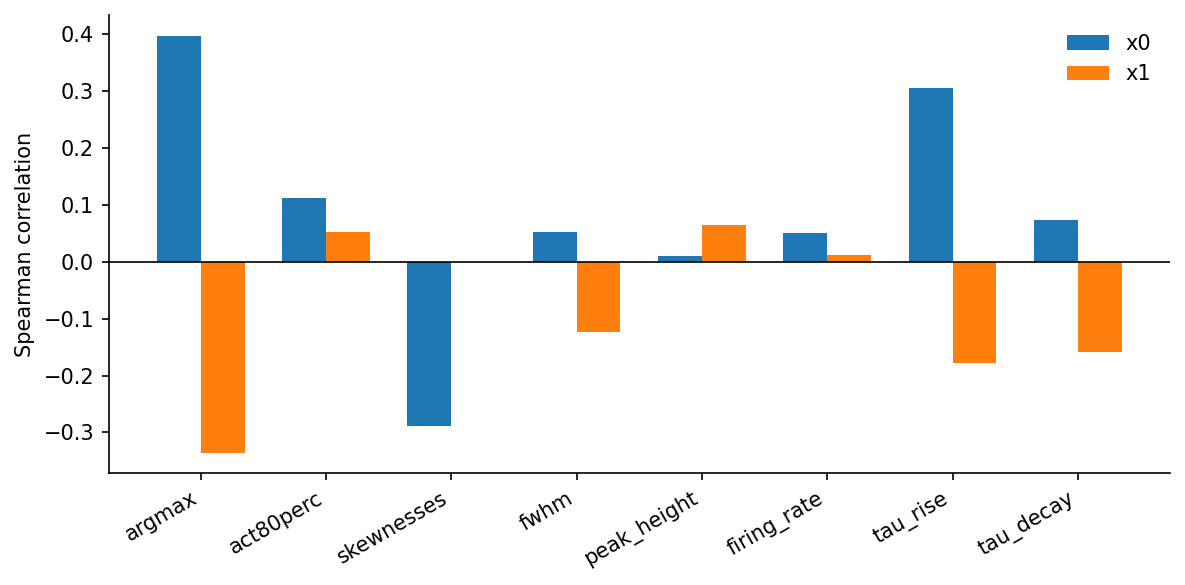

In [282]:
import matplotlib.pyplot as plt

df = df_all
features = [
    "argmax",
    "act80perc",
    "skewnesses",
    "fwhm",
    "peak_height",
    "firing_rate",
    "tau_rise",
    "tau_decay",
]

corr_x0 = []
corr_x1 = []
corr_x0_pval = []
corr_x1_pval = []
n_x0 = []
n_x1 = []

for feat in features:
    rho0, p0 = spearman_ignore_nan(df["x0"], df[feat])
    rho1, p1 = spearman_ignore_nan(df["x1"], df[feat])

    corr_x0.append(rho0)
    corr_x1.append(rho1)
    corr_x0_pval.append(p0)
    corr_x1_pval.append(p1)

    # Number of valid pairs, useful for checking tau_rise
    n_x0.append(
        np.sum(
            np.isfinite(np.asarray(df["x0"], dtype=float))
            & np.isfinite(np.asarray(df[feat], dtype=float))
        )
    )
    n_x1.append(
        np.sum(
            np.isfinite(np.asarray(df["x1"], dtype=float))
            & np.isfinite(np.asarray(df[feat], dtype=float))
        )
    )


x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width / 2, corr_x0, width, label="x0")
ax.bar(x + width / 2, corr_x1, width, label="x1")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha="right")
ax.set_ylabel("Spearman correlation")
# ax.set_title('Mossink')
ax.legend(frameon=False)

sns.despine(ax=ax)
plt.tight_layout()

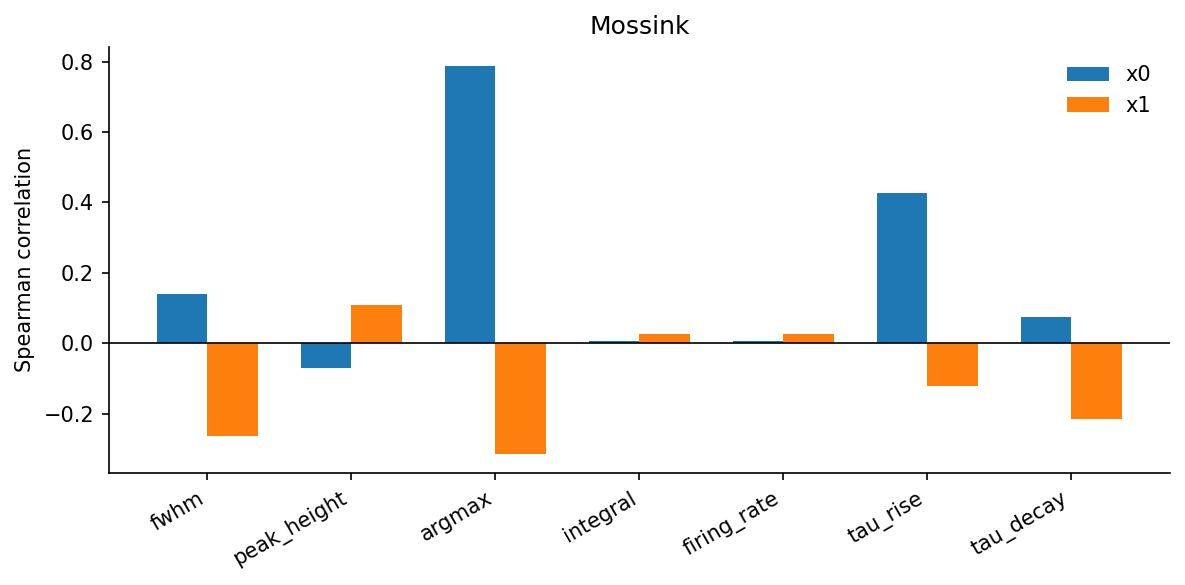

In [281]:
import matplotlib.pyplot as plt

df = df_mossink
features = [
    "fwhm",
    "peak_height",
    "argmax",
    "integral",
    "firing_rate",
    "tau_rise",
    "tau_decay",
]

corr_x0 = []
corr_x1 = []
corr_x0_pval = []
corr_x1_pval = []
n_x0 = []
n_x1 = []

for feat in features:
    rho0, p0 = spearman_ignore_nan(df["x0"], df[feat])
    rho1, p1 = spearman_ignore_nan(df["x1"], df[feat])

    corr_x0.append(float(rho0))
    corr_x1.append(float(rho1))
    corr_x0_pval.append(p0)
    corr_x1_pval.append(p1)

    # Number of valid pairs, useful for checking tau_rise
    n_x0.append(
        np.sum(
            np.isfinite(np.asarray(df["x0"], dtype=float))
            & np.isfinite(np.asarray(df[feat], dtype=float))
        )
    )
    n_x1.append(
        np.sum(
            np.isfinite(np.asarray(df["x1"], dtype=float))
            & np.isfinite(np.asarray(df[feat], dtype=float))
        )
    )


x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(x - width / 2, corr_x0, width, label="x0")
ax.bar(x + width / 2, corr_x1, width, label="x1")

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha="right")
ax.set_ylabel("Spearman correlation")
ax.set_title("Mossink")
ax.legend(frameon=False)

sns.despine(ax=ax)
plt.tight_layout()

## Per-dataset correlation comparison
Same Spearman correlation bars as above, but computed separately per dataset and grouped on the same axis for comparison.

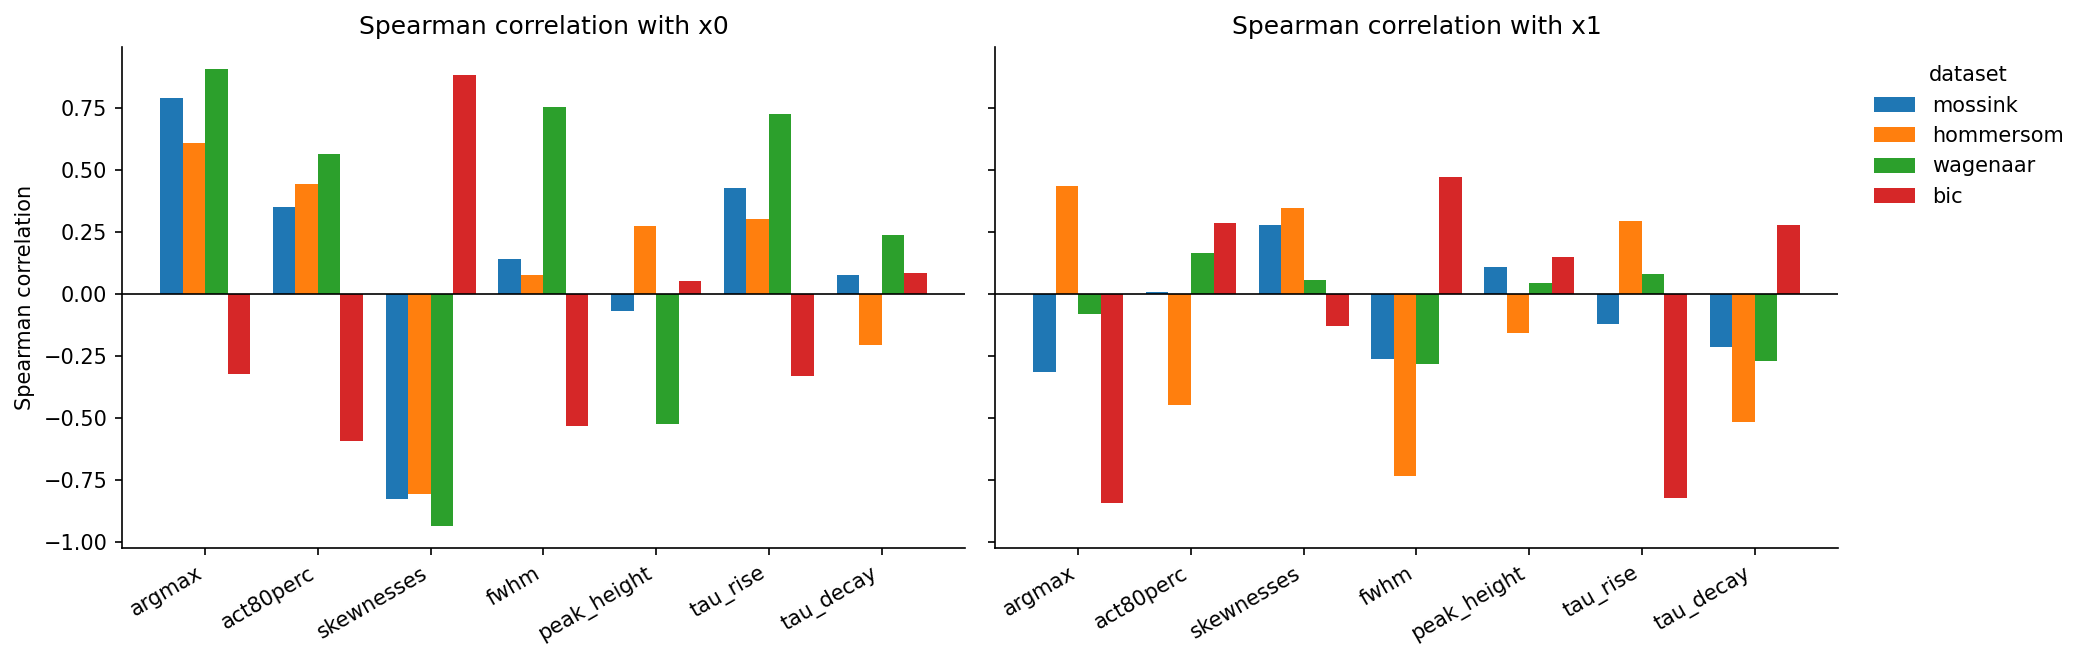

In [299]:
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    "argmax",
    "act80perc",
    "skewnesses",
    "fwhm",
    "peak_height",
    "tau_rise",
    "tau_decay",
]
datasets = {
    "mossink": df_mossink,
    "hommersom": df_hommersom,
    "wagenaar": df_wagenaar,
    "bic": df_bic,
}
colors = dict(
    zip(datasets, sns.color_palette("tab10", n_colors=len(datasets)), strict=False)
)

corr_x0 = {name: [] for name in datasets}
corr_x1 = {name: [] for name in datasets}
for name, d in datasets.items():
    for feat in features:
        rho0, _ = spearman_ignore_nan(d["x0"], d[feat])
        rho1, _ = spearman_ignore_nan(d["x1"], d[feat])
        corr_x0[name].append(float(rho0))
        corr_x1[name].append(float(rho1))

x = np.arange(len(features))
n_ds = len(datasets)
width = 0.8 / n_ds

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, corr, coord in zip(axes, [corr_x0, corr_x1], ["x0", "x1"], strict=False):
    for i, (name, vals) in enumerate(corr.items()):
        ax.bar(
            x + (i - (n_ds - 1) / 2) * width,
            vals,
            width,
            label=name,
            color=colors[name],
        )
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=30, ha="right")
    ax.set_title(f"Spearman correlation with {coord}")
    sns.despine(ax=ax)

axes[0].set_ylabel("Spearman correlation")
axes[1].legend(
    frameon=False, title="dataset", bbox_to_anchor=(1.02, 1), loc="upper left"
)
plt.tight_layout()

corr_df_x0 = pd.DataFrame(corr_x0, index=features)
corr_df_x1 = pd.DataFrame(corr_x1, index=features)

In [294]:
corr_df_x1

,mossink,hommersom,wagenaar,bic
argmax,-0.314679,0.434275,-0.083845,-0.845971
act80perc,0.004861,-0.450306,0.165055,0.287271
skewnesses,0.277815,0.344150,0.055325,-0.130446
fwhm,-0.262271,-0.735200,-0.285493,0.469133
peak_height,0.108876,-0.160080,0.043652,0.148266
firing_rate,0.024952,-0.286887,-0.262372,0.123593
tau_rise,-0.122279,0.294078,0.081127,-0.824429
tau_decay,-0.214453,-0.517927,-0.270068,0.278832


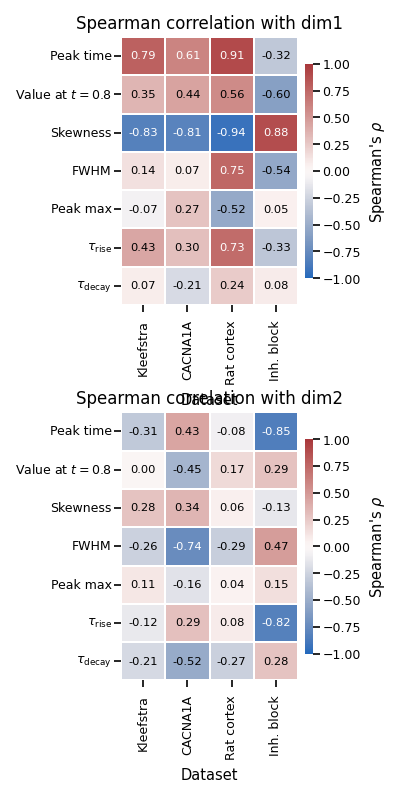

In [314]:
plt.rcParams.update(
    {
        "font.size": 6.5,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
    }
)

fig, axes = plt.subplots(2, 1, figsize=(64.1 / 25.4, 128.2 / 25.4), sharey=True)

for ax, corr_df, coord in zip(
    axes, [corr_df_x0, corr_df_x1], ["dim1", "dim2"], strict=False
):
    hm = sns.heatmap(
        corr_df,
        ax=ax,
        cmap="vlag",
        vmin=-1,
        vmax=1,
        center=0,
        annot=False,
        cbar=True,
        linewidths=0.1,
        linecolor="white",
        cbar_kws={
            "shrink": 0.8,
            "aspect": 25,
            "pad": 0.03,
        },
    )

    for (row, col), val in np.ndenumerate(corr_df.to_numpy()):
        ax.text(
            col + 0.5,
            row + 0.5,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=5.5,
            color="white" if abs(val) > 0.6 else "black",
        )

    ax.set_title(
        f"Spearman correlation with {coord}",
        fontsize=8,
        pad=4,
    )
    ax.set_xlabel("Dataset", fontsize=7)

    ax.set_xticklabels(
        ["Kleefstra", "CACNA1A", "Rat cortex", "Inh. block"],
        rotation=90,
        ha="center",
        fontsize=6,
    )

    ax.tick_params(axis="y", labelsize=6, pad=1)

    cbar = hm.collections[0].colorbar
    cbar.ax.tick_params(labelsize=6, pad=1)
    cbar.ax.set_ylabel(
        r"Spearman's $\rho$",
        fontsize=7,
        rotation=90,
        labelpad=8,
        va="center",
    )

fig.subplots_adjust(
    left=0.31,
    right=0.88,
    top=0.95,
    bottom=0.10,
    hspace=0.40,
)

savefig(fig, "heatmap_check", file_format=["pdf"])